In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris # pip install scikit-learn
import seaborn as sns

In [2]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Class'] = data.target

# rename the columns
df.rename(columns={'sepal length (cm)': 'SepalLengthCm',
                   'sepal width (cm)': 'SepalWidthCm',
                   'petal length (cm)': 'PetalLengthCm',
                   'petal width (cm)': 'PetalWidthCm'}, inplace=True)
df.head()

def class_label(val):
    if val == 0:
        return 'Setosa'
    elif val == 1:
        return 'Versicolor'
    else:
        return 'Virginica'

df['Class'] = df['Class'].apply(class_label)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Class
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [3]:
# Problem Statement: Perform Exploratory Data Analysis (EDA) 
# on the Iris dataset to understand 
# the distribution and relationships 
# of features across different species of Iris flowers.
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Class          150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.Class.value_counts()

Class
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

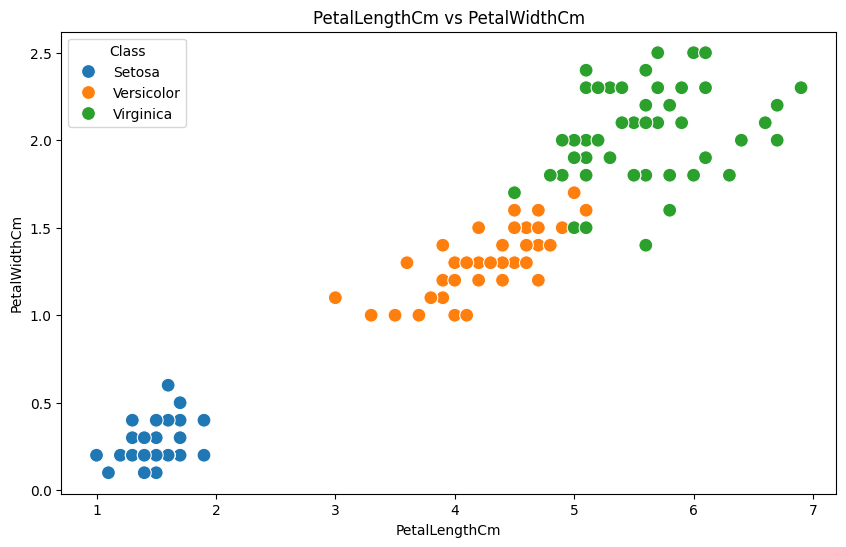

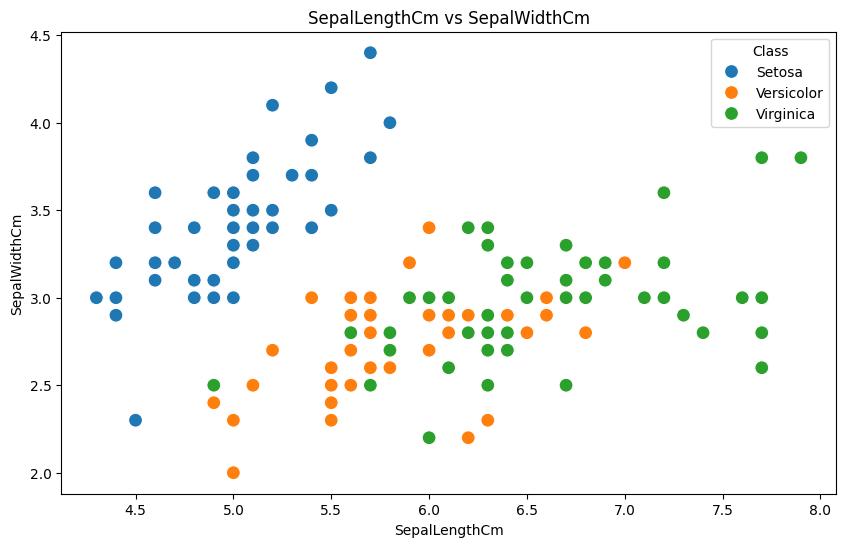

In [5]:
# 2D scatter plot
# wrap inside a function for reuse
def plot_scatter(x_col, y_col):
    plt.figure(figsize=(10,6)) 
    sns.scatterplot(data=df, x=x_col, y=y_col, hue='Class', s=100)
    plt.title(f'{x_col} vs {y_col}')
    plt.show()

plot_scatter('PetalLengthCm', 'PetalWidthCm')
plot_scatter('SepalLengthCm', 'SepalWidthCm')


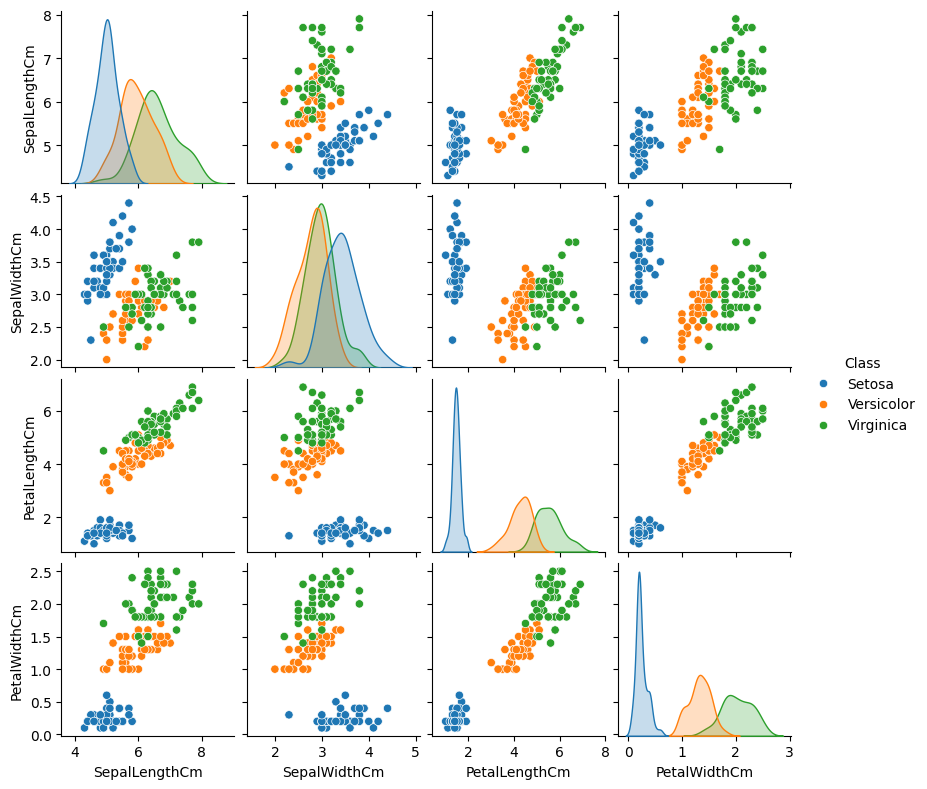

In [6]:
# pairplot
sns.pairplot(df, hue='Class', height=2)
plt.show()

In [7]:
# 3d scatter plot : plotly
import plotly.express as px  # pip install plotly

fig = px.scatter_3d(df, 
                    x='SepalLengthCm', 
                    y='SepalWidthCm', 
                    z='PetalLengthCm', 
                    color='Class', 
                    size='PetalWidthCm',
                    title='3D Scatter plot of Iris dataset')
fig.show()


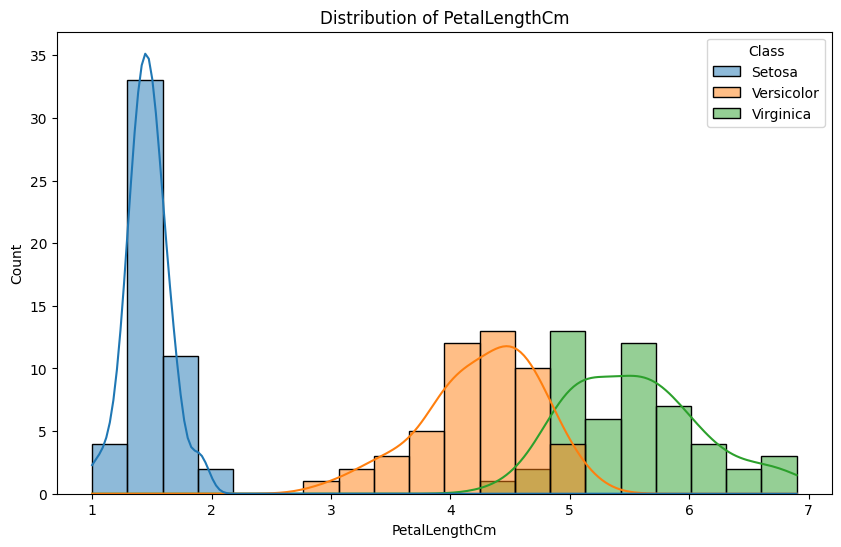

In [8]:
# 1 D histogram
# plt.figure(figsize=(10,6))
# sns.histplot(data=df, x='SepalLengthCm', hue='Class', kde=True, bins=20)
# plt.title('Distribution of Sepal Length')
# plt.show()

# wrap inside a function for reuse
def plot_histogram(column):
    plt.figure(figsize=(10,6))
    sns.histplot(data=df, x=column, hue='Class', kde=True, bins=20)
    plt.title(f'Distribution of {column}')
    plt.show()
plot_histogram('PetalLengthCm')

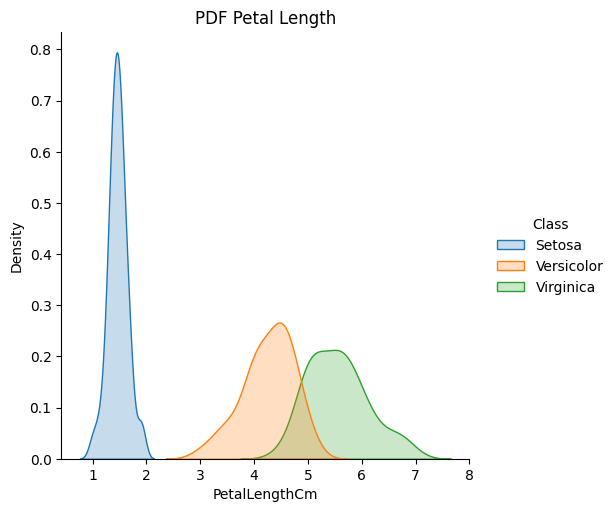

In [9]:
# using pdf - > cdf
sns.displot(df, x='PetalLengthCm', hue='Class', kind='kde', fill=True)
plt.title('PDF Petal Length')
plt.show()

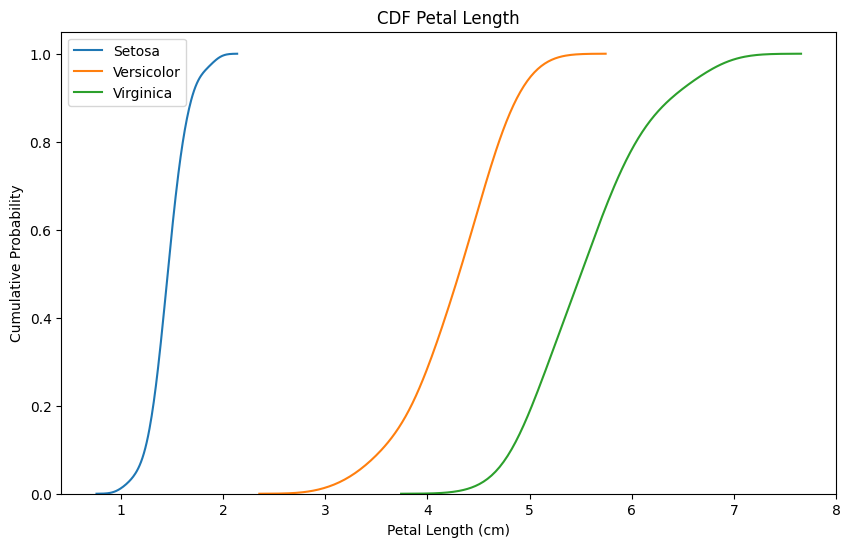

In [10]:
# for CDF
plt.figure(figsize=(10,6))
for species in df['Class'].unique():
    subset = df[df['Class'] == species]
    sns.kdeplot(subset['PetalLengthCm'], cumulative=True, label=species)
plt.title('CDF Petal Length')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()

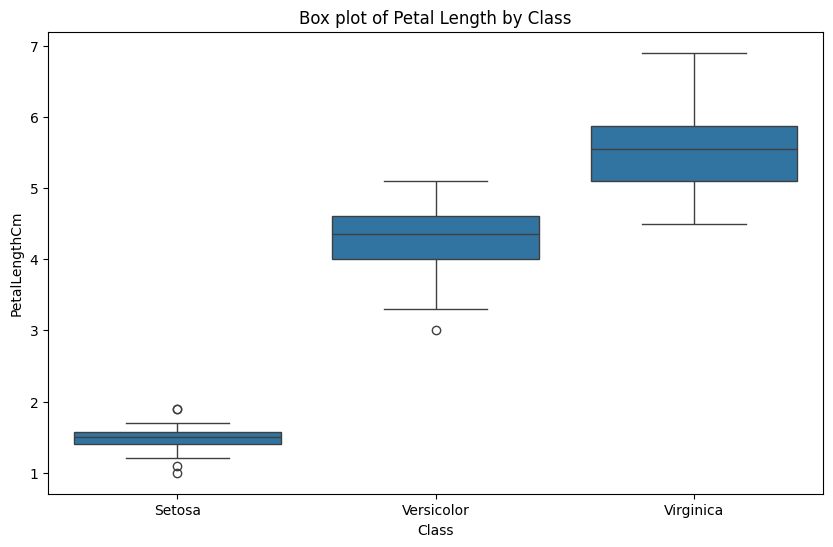

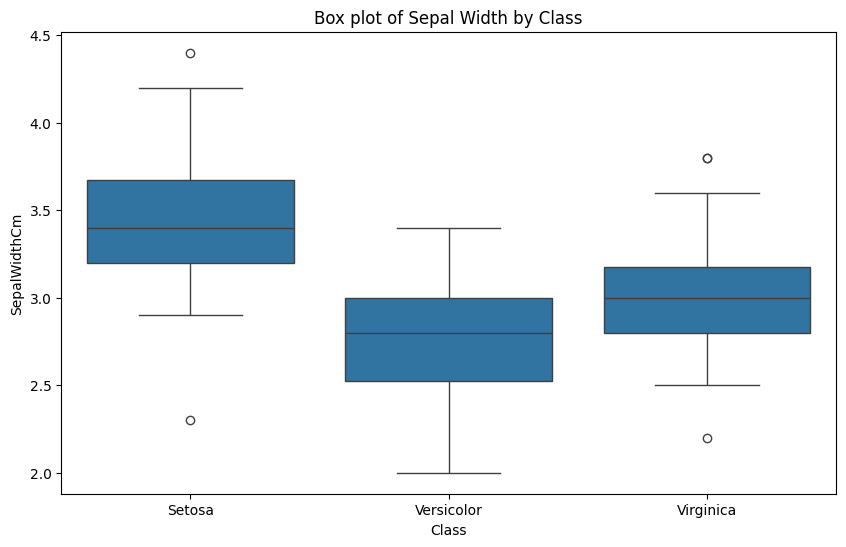

In [11]:
# box plot
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='PetalLengthCm')
plt.title('Box plot of Petal Length by Class')
plt.show()

# use of box plot to identify outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='SepalWidthCm')
plt.title('Box plot of Sepal Width by Class')
plt.show()

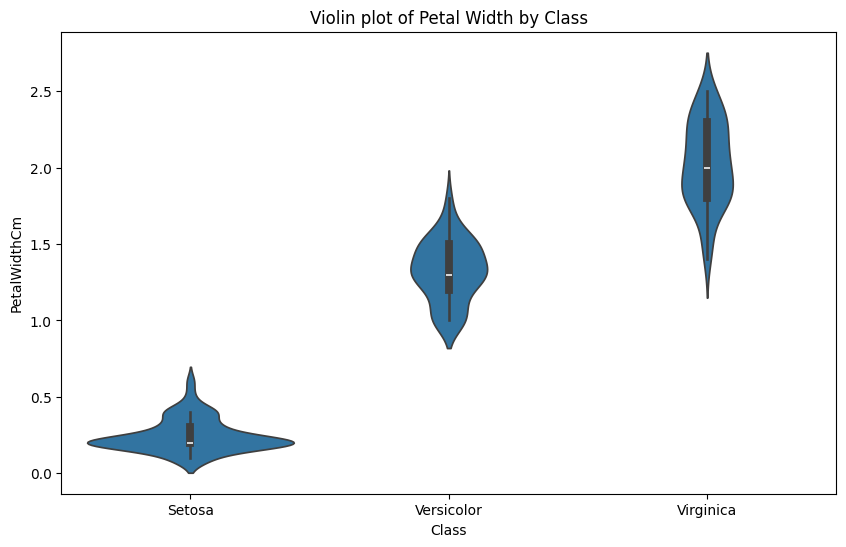

In [12]:
# voiolin plot
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Class', y='PetalWidthCm')
plt.title('Violin plot of Petal Width by Class')
plt.show()

In [13]:
# assignment :
# Build Rule engine using if else
# based on feature thresholds
# to classify the species of Iris flower

def classify_iris(row):
    if row['SepalLengthCm'] < 5.0 and row['PetalLengthCm'] < 2.0:
        if row['PetalWidthCm'] < 0.2:
            return 'Setosa'
    elif 5.0 <= row['SepalLengthCm'] < 6.5 and 2.0 <= row['PetalLengthCm'] < 5.0:
        return 'Versicolor'
    else:
        return 'Virginica'

df['PredictedSpecies'] = df.apply(classify_iris, axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Class,PredictedSpecies
0,5.1,3.5,1.4,0.2,Setosa,Virginica
1,4.9,3.0,1.4,0.2,Setosa,None
2,4.7,3.2,1.3,0.2,Setosa,None
3,4.6,3.1,1.5,0.2,Setosa,None
4,5.0,3.6,1.4,0.2,Setosa,Virginica


In [14]:
# pandas profile report
# pip install ydata-profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Iris Dataset Profiling Report", explorative=True)
profile.to_file("iris_dataset_profile_report.html")

ModuleNotFoundError: No module named 'pkg_resources'